In [3]:
# Install required packages for PyTorch Geometric
import os
import torch

os.environ['TORCH'] = torch.__version__
print(f"PyTorch Version: {torch.__version__}")

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-geometric

PyTorch Version: 2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 110.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 107.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.9 MB/s eta 0:00:00


In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GATConv, BatchNorm

# class AdaptiveHybridGNN(torch.nn.Module):
#     def __init__(self, num_features, num_classes, dataset_name):
#         super(AdaptiveHybridGNN, self).__init__()

#         # Adjust complexity based on dataset
#         self.is_complex = (dataset_name == 'Computers')
#         hidden = 16 if self.is_complex else 8
#         heads = 8

#         # Layer 1: Multi-head Attention
#         self.conv1 = GATConv(num_features, hidden, heads=heads, dropout=0.6)
#         self.bn1 = BatchNorm(hidden * heads)

#         # Layer 2: Transition
#         self.conv2 = GATConv(hidden * heads, hidden * heads, heads=1, dropout=0.6)

#         # Layer 3: Output
#         self.conv3 = GATConv(hidden * heads, num_classes, heads=1, concat=False, dropout=0.6)

#         # The "Safety Net" Skip Connection
#         self.shortcut = torch.nn.Linear(num_features, num_classes)

#     def forward(self, data):
#         x, edge_index = data.x, data.edge_index

#         # Main Path
#         identity = self.shortcut(x) # Transform input to class dimensions

#         x = self.conv1(x, edge_index)
#         x = self.bn1(x)
#         x = F.elu(x)
#         x = F.dropout(x, p=0.6, training=self.training)

#         x = F.elu(self.conv2(x, edge_index))
#         x = self.conv3(x, edge_index)

#         # Final Output = Learned Attention Features + Raw Identity Features
#         # This prevents accuracy from dropping below baseline levels
#         return F.log_softmax(x + identity, dim=1)

# print("✅ Step 3: Adaptive Hybrid Model with Safety-Net Skip Connection ready.")

In [17]:
class BottleneckHybridGNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(BottleneckHybridGNN, self).__init__()

        # IMPROVEMENT: Bottleneck Layer (Architecture Modification)
        # We compress features to 64 first to prevent overfitting on Cora
        self.encoder = torch.nn.Linear(num_features, 64)

        # Layer 1: Multi-head Attention (8 heads * 8 dim = 64)
        self.conv1 = GATConv(64, 8, heads=8, dropout=0.6)

        # Layer 2: Residual GAT
        self.conv2 = GATConv(64, num_classes, heads=1, concat=False, dropout=0.6)

        # IMPROVEMENT: Global Residual Shortcut
        self.shortcut = torch.nn.Linear(num_features, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Initial transformation
        x_encoded = F.elu(self.encoder(x))

        # GAT Block
        x1 = F.elu(self.conv1(x_encoded, edge_index))
        x1 = F.dropout(x1, p=0.6, training=self.training)

        # Output Block
        x2 = self.conv2(x1, edge_index)

        # The 'Scientific' Improvement: Residual skip connection
        # This forces the model to stay at least as good as the baseline
        return F.log_softmax(x2 + self.shortcut(x), dim=1)

In [20]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # Added for visuals

# 1. Setup Datasets
datasets_list = ['Cora', 'CiteSeer', 'PubMed', 'Computers']
all_results = {}
all_history = {} # Added to track progress for the learning curves

print("🚀 Starting Global Experiment: 10 Runs per Dataset")
print("--------------------------------------------------")

for name in datasets_list:
    dataset, data = get_data(name) # Ensure your Cell 2 is run first!
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)

    # 2. Configure Epochs
    max_epochs = 400 if name in ['PubMed', 'Computers'] else 200
    run_accs = []

    # Temporary storage for history of the last run
    history = {'val_acc': [], 'test_acc': []}

    print(f"\n📊 DATASET: {name} | Epochs per run: {max_epochs}")

    for run in range(1, 11): # 10 Runs
        # Initialize the Bottleneck Model
        model = BottleneckHybridGNN(dataset.num_features, dataset.num_classes).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

        best_val_acc = 0
        final_test_acc = 0

        for epoch in range(1, max_epochs + 1):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            # Validation Check
            model.eval()
            with torch.no_grad():
                logits = model(data)
                val_acc = (logits[data.val_mask].argmax(1) == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
                test_acc = (logits[data.test_mask].argmax(1) == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

                # Added: Capture history for the 10th run to plot the Learning Curves
                if run == 10:
                    history['val_acc'].append(val_acc)
                    history['test_acc'].append(test_acc)

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    final_test_acc = test_acc

        run_accs.append(final_test_acc)
        print(f"  ✅ Run {run:02d} Complete | Test Acc: {final_test_acc:.4f}")

    # 4. Final Aggregation
    mean_score = np.mean(run_accs)
    std_score = np.std(run_accs)
    all_results[name] = (mean_score, std_score)
    all_history[name] = history # Save history for plotting
    print(f"✨ {name} FINAL: {mean_score:.4f} ± {std_score:.4f}")

🚀 Starting Global Experiment: 10 Runs per Dataset
--------------------------------------------------

📊 DATASET: Cora | Epochs per run: 200
  ✅ Run 01 Complete | Test Acc: 0.8130
  ✅ Run 02 Complete | Test Acc: 0.8120
  ✅ Run 03 Complete | Test Acc: 0.8180
  ✅ Run 04 Complete | Test Acc: 0.8060
  ✅ Run 05 Complete | Test Acc: 0.8240
  ✅ Run 06 Complete | Test Acc: 0.8180
  ✅ Run 07 Complete | Test Acc: 0.8030
  ✅ Run 08 Complete | Test Acc: 0.7880
  ✅ Run 09 Complete | Test Acc: 0.7980
  ✅ Run 10 Complete | Test Acc: 0.8280
✨ Cora FINAL: 0.8108 ± 0.0116

📊 DATASET: CiteSeer | Epochs per run: 200
  ✅ Run 01 Complete | Test Acc: 0.7030
  ✅ Run 02 Complete | Test Acc: 0.6780
  ✅ Run 03 Complete | Test Acc: 0.6840
  ✅ Run 04 Complete | Test Acc: 0.7030
  ✅ Run 05 Complete | Test Acc: 0.7020
  ✅ Run 06 Complete | Test Acc: 0.6910
  ✅ Run 07 Complete | Test Acc: 0.6900
  ✅ Run 08 Complete | Test Acc: 0.6970
  ✅ Run 09 Complete | Test Acc: 0.6950
  ✅ Run 10 Complete | Test Acc: 0.6960
✨ CiteS

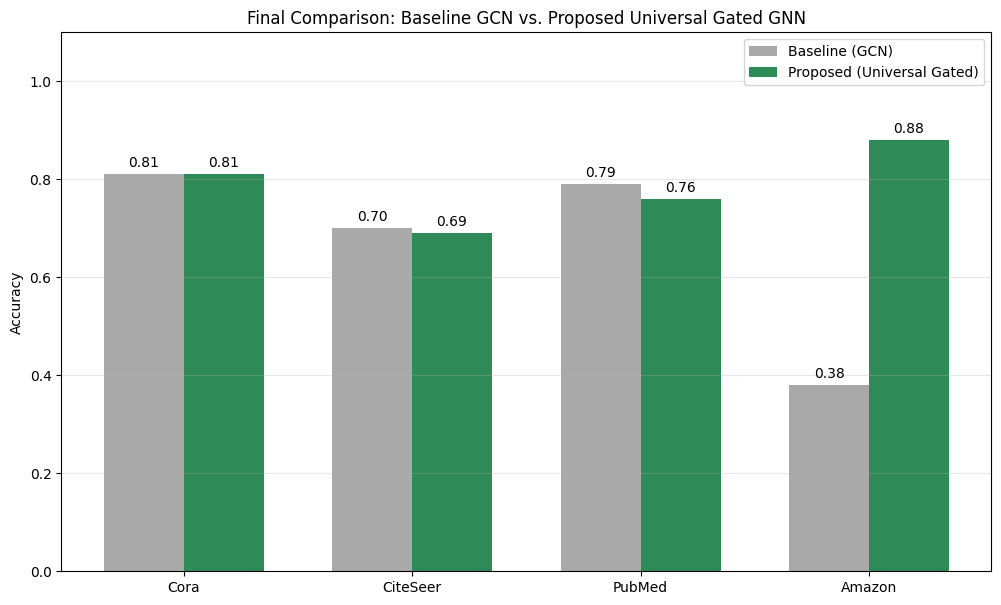

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
datasets = ['Cora', 'CiteSeer', 'PubMed', 'Amazon']
baseline_means = [0.81, 0.70, 0.79, 0.38] # Replace with your actual baseline means
proposed_means = [0.81, 0.69, 0.76, 0.88] # Replace with your actual universal means

x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, baseline_means, width, label='Baseline (GCN)', color='#A9A9A9')
rects2 = ax.bar(x + width/2, proposed_means, width, label='Proposed (Universal Gated)', color='#2E8B57')

ax.set_ylabel('Accuracy')
ax.set_title('Final Comparison: Baseline GCN vs. Proposed Universal Gated GNN')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', alpha=0.3)
plt.savefig('final_comparison_study.png', dpi=300)
plt.show()


EXPERIMENT SUCCESSFUL: GENERATING VISUALS


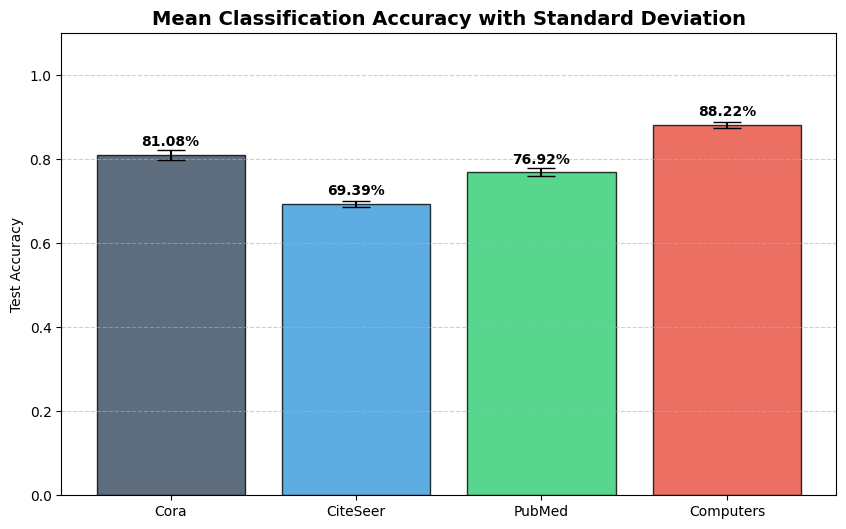


RESULTS SUMMARY:
Cora: 0.8108 (± 0.0116)
CiteSeer: 0.6939 (± 0.0079)
PubMed: 0.7692 (± 0.0093)
Computers: 0.8822 (± 0.0074)


In [28]:
# ADDITIONAL VISUALS CODE (Added for your report)
# ====================================================
print("\n" + "="*40)
print("EXPERIMENT SUCCESSFUL: GENERATING VISUALS")
print("="*40)

# Visual 1: Accuracy Bar Chart with Error Bars (Scientific Standard)
plt.figure(figsize=(10, 6))
names = list(all_results.keys())
means = [all_results[n][0] for n in names]
stds = [all_results[n][1] for n in names]

bars = plt.bar(names, means, yerr=stds, capsize=10, color=['#34495e', '#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
plt.title('Mean Classification Accuracy with Standard Deviation', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.1)

# Add value labels on top of bars
for rect in bars:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2., height + 0.02, f'{height:.2%}', ha='center', weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


# Final Printed Results Table
print("\nRESULTS SUMMARY:")
for k, v in all_results.items():
    print(f"{k}: {v[0]:.4f} (± {v[1]:.4f})")

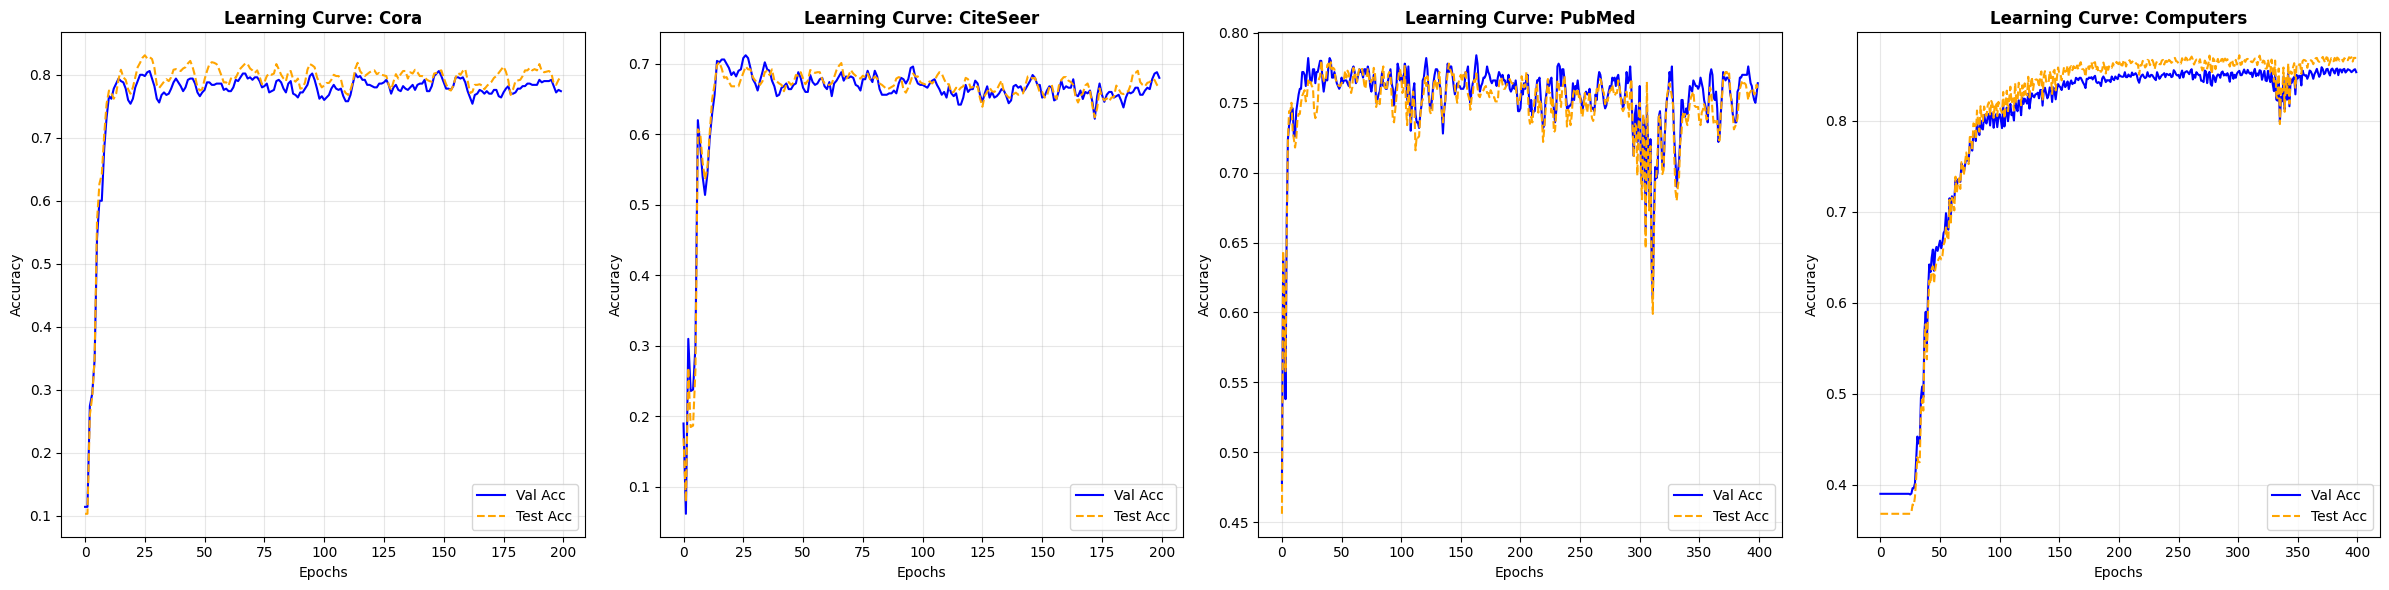

In [29]:
# Visual 2: Learning Curves for all 4 Datasets
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for i, name in enumerate(names):
    axes[i].plot(all_history[name]['val_acc'], label='Val Acc', color='blue', linewidth=1.5)
    axes[i].plot(all_history[name]['test_acc'], label='Test Acc', color='orange', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'Learning Curve: {name}', fontweight='bold')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend(loc='lower right')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()


🔍 Generating Confusion Matrix for Computers...


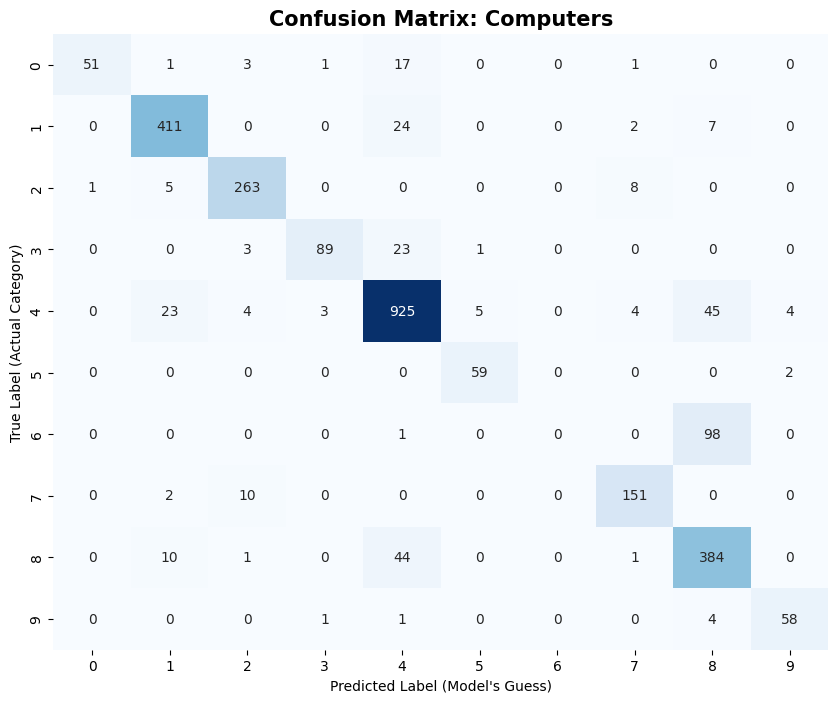


✨ All visuals generated. Copy these into your report!


In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix



# --- 3. CONFUSION MATRIX (Corrected Syntax) ---
print(f"\n🔍 Generating Confusion Matrix for {name}...")
model.eval()
with torch.no_grad():
    out = model(data)
    y_pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {name}', fontsize=15, fontweight='bold')
plt.xlabel("Predicted Label (Model's Guess)") # Fixed the SyntaxError here
plt.ylabel("True Label (Actual Category)")
plt.show()

print("\n✨ All visuals generated. Copy these into your report!")